# Support Vector Machine — TensorFlow (CPU Tensor Ops)

**Dataset:** MAGIC Gamma Telescope (UCI) — 18,905 samples, 10 features, binary classification  
**Task:** Classify cosmic ray observations as gamma rays (signal) or hadrons (background noise)  
**Algorithm:** Projected gradient ascent on the SVM dual objective (TF CPU tensors)  
**Framework showcase:** Kernel Comparison — linear vs RBF vs polynomial

## CPU Tensor Strategy

Same dual gradient descent algorithm as No-Framework and PyTorch, but using TensorFlow's eager-mode tensor operations on CPU. TF 2.11+ dropped native Windows GPU support, so all ops run on CPU.

Key TF operations in the training loop:
- **Kernel matrix**: `X1 @ tf.transpose(X2)` — standard matmul (both 2D)
- **Gradient matmul**: `tf.linalg.matvec(K, alpha * y)` — O(n²) matrix-vector product each iteration
- **Dot products**: `tf.reduce_sum(a * b)` — element-wise multiply then reduce
- **Constraint projection**: `tf.clip_by_value(alpha, 0, C)` + equality fix via `tf.boolean_mask`

Platt calibration runs on numpy via shared `svm_utils.py` (same as all from-scratch frameworks).

## Hyperparameters (from Scikit-Learn tuning)
- **Kernel**: Polynomial (degree=3, coef0=1)
- **C**: 10.0
- **gamma**: 1 / (n_features × X_train.var()) ≈ 'scale'

In [1]:
# Step 1: Imports, Configuration, and Data Loading
import sys
import os
import numpy as np
import tensorflow as tf

# Add project root to path for shared utilities
sys.path.insert(0, os.path.abspath('../..'))

from utils.data_loader import load_processed_data
from utils.metrics import evaluate_classifier, print_metrics
from utils.performance import track_performance, track_inference, get_model_size
from utils.visualization import (plot_confusion_matrix, plot_roc_curve,
                                  plot_calibration_curve, plot_kernel_comparison,
                                  plot_svm_convergence)
from utils.results import save_results, add_result, print_comparison, build_results_dict
from utils.svm_utils import to_svm_labels, to_std_labels, platt_calibrate, platt_predict_proba

# Configuration — hyperparameters from Scikit-Learn tuning
RANDOM_STATE = 113
FRAMEWORK = 'TensorFlow'
RESULTS_DIR = 'results'
os.makedirs(RESULTS_DIR, exist_ok=True)

C = 10.0               # Regularization (from SK C sweep)
DEGREE = 3             # Polynomial degree (from SK kernel comparison)
COEF0 = 1              # Polynomial coef0
N_ITERS = 3000         # Dual gradient descent iterations

# Set TF random seed
tf.random.set_seed(RANDOM_STATE)

# Load preprocessed data (numpy arrays)
X_train_np, X_test_np, y_train, y_test, metadata = load_processed_data('svm')

# Compute gamma = 'scale' (same as sklearn) — on numpy BEFORE tensor conversion
GAMMA = 1.0 / (X_train_np.shape[1] * X_train_np.var())

# Convert labels: {0, 1} -> {-1, +1} for SVM math (numpy — svm_utils is numpy-only)
y_train_svm = to_svm_labels(y_train)
y_test_svm = to_svm_labels(y_test)

# Convert features to TF tensors (float32, CPU)
X_train = tf.constant(X_train_np, dtype=tf.float32)
X_test = tf.constant(X_test_np, dtype=tf.float32)

# Labels as TF tensor (for element-wise ops in training loop)
y_train_t = tf.constant(y_train_svm, dtype=tf.float32)

print(f"\n{'=' * 60}")
print(f"SUPPORT VECTOR MACHINE — {FRAMEWORK}")
print(f"{'=' * 60}")
print(f"\nDataset: {metadata['dataset']}")
print(f"Features: {metadata['n_features']} (all continuous, StandardScaler applied)")
print(f"Training: {X_train.shape[0]:,} samples")
print(f"Test:     {X_test.shape[0]:,} samples")
print(f"Classes:  {metadata['class_names']}")
print(f"Device:   CPU (TF 2.11+ dropped native Windows GPU)")
print(f"Dtype:    {X_train.dtype.name}")
print(f"\nHyperparameters (from Scikit-Learn tuning):")
print(f"  C={C}, kernel=poly, degree={DEGREE}, coef0={COEF0}")
print(f"  gamma={GAMMA:.6f} (1 / (n_features * X.var()))")
print(f"  n_iters={N_ITERS}")

# Memory estimate for full kernel matrix
n = X_train.shape[0]
mem_gb = (n * n * 4) / (1024 ** 3)  # float32 = 4 bytes
print(f"\n  Kernel matrix: {n:,} x {n:,} = {n*n:,} entries")
print(f"  Memory: {mem_gb:.2f} GB (float32, CPU RAM)")


SUPPORT VECTOR MACHINE — TensorFlow

Dataset: MAGIC Gamma Telescope (UCI)
Features: 10 (all continuous, StandardScaler applied)
Training: 15,124 samples
Test:     3,781 samples
Classes:  ['hadron (background)', 'gamma (signal)']
Device:   CPU (TF 2.11+ dropped native Windows GPU)
Dtype:    float32

Hyperparameters (from Scikit-Learn tuning):
  C=10.0, kernel=poly, degree=3, coef0=1
  gamma=0.100000 (1 / (n_features * X.var()))
  n_iters=3000

  Kernel matrix: 15,124 x 15,124 = 228,735,376 entries
  Memory: 0.85 GB (float32, CPU RAM)


In [2]:
# Step 2: TF Kernel Functions
print("=" * 60)
print("STEP 2: TF KERNEL FUNCTIONS")
print("=" * 60)

"""
Same 3 kernels as No-Framework/PyTorch, but using TF eager-mode ops.
All operations (matmul, exp, reduce_sum) run on CPU tensors.
float32 vs NF's float64 — halves memory, negligible precision impact
for kernel values in the ~O(1-10) range with scaled data.
"""

def linear_kernel_tf(X1, X2):
    """Linear kernel: K(x, z) = x^T z — standard matmul (both 2D)."""
    return X1 @ tf.transpose(X2)


def rbf_kernel_tf(X1, X2, gamma):
    """
    RBF kernel: K(x, z) = exp(-gamma * ||x - z||^2)
    
    Expand ||x-z||^2 = ||x||^2 + ||z||^2 - 2*x^Tz to avoid
    creating an (n1, n2, d) intermediate tensor.
    """
    sq1 = tf.expand_dims(tf.reduce_sum(X1 ** 2, axis=1), axis=1)  # (n1, 1)
    sq2 = tf.expand_dims(tf.reduce_sum(X2 ** 2, axis=1), axis=0)  # (1, n2)
    dist_sq = sq1 + sq2 - 2.0 * (X1 @ tf.transpose(X2))          # (n1, n2)
    return tf.exp(-gamma * dist_sq)


def poly_kernel_tf(X1, X2, gamma, degree, coef0):
    """Polynomial kernel: K(x, z) = (gamma * x^T z + coef0)^degree"""
    return (gamma * (X1 @ tf.transpose(X2)) + coef0) ** degree


# Quick test: verify shapes and symmetry on 100 CPU samples
print("\nQuick test on 100 samples...")
X_small = X_train[:100]

K_lin = linear_kernel_tf(X_small, X_small)
K_rbf = rbf_kernel_tf(X_small, X_small, GAMMA)
K_poly = poly_kernel_tf(X_small, X_small, GAMMA, DEGREE, COEF0)

for name, K in [('Linear', K_lin), ('RBF', K_rbf), ('Poly', K_poly)]:
    is_symmetric = np.allclose(K.numpy(), tf.transpose(K).numpy())
    diag_check = float(K[0, 0].numpy())
    print(f"  {name:8s}: shape={tuple(K.shape)}, symmetric={is_symmetric}, "
          f"K[0,0]={diag_check:.4f}")

print(f"\n  RBF K[0,0] = {float(K_rbf[0,0].numpy()):.6f} (should be 1.0)")
print(f"  RBF K[0,1] = {float(K_rbf[0,1].numpy()):.6f} (similarity between sample 0 and 1)")
print(f"  Dtype: {K_poly.dtype.name}")

STEP 2: TF KERNEL FUNCTIONS

Quick test on 100 samples...
  Linear  : shape=(100, 100), symmetric=True, K[0,0]=5.3309
  RBF     : shape=(100, 100), symmetric=True, K[0,0]=1.0000
  Poly    : shape=(100, 100), symmetric=True, K[0,0]=3.6033

  RBF K[0,0] = 1.000000 (should be 1.0)
  RBF K[0,1] = 0.913836 (similarity between sample 0 and 1)
  Dtype: float32


In [3]:
# Step 3: Dual Gradient Descent + Predict
print("=" * 60)
print("STEP 3: DUAL GRADIENT DESCENT")
print("=" * 60)

"""
Same projected gradient ascent as No-Framework/PyTorch, but all operations
run on CPU TF tensors. The O(n²) matvec K @ (alpha * y) each iteration
is where most compute goes — CPU-bound here unlike PyTorch's GPU version.

Key TF translations from PyTorch:
  torch.dot(a, b) → tf.reduce_sum(a * b)  (no tf.dot exists)
  K @ ay → tf.linalg.matvec(K, ay)  (matrix-vector, @ needs 2D+)
  torch.clamp(a, 0, C) → tf.clip_by_value(a, 0, C)
  torch.sign() → tf.sign()
  obj.item() → float(obj.numpy())
"""

def train_dual_svm_tf(K, y, C, n_iters=3000, verbose=True):
    """
    Train SVM via projected gradient ascent on the dual objective (TF CPU).
    
    Same algorithm as NF/PyTorch: gradient → adaptive LR → ascent → project.
    All ops on CPU TF tensors, objectives stored as Python floats.
    
    Args:
        K: (n, n) precomputed kernel matrix (TF tensor)
        y: (n,) labels in {-1, +1} (TF tensor, float32)
        C: regularization parameter (Python float)
        n_iters: gradient ascent iterations
        verbose: print progress every 500 iterations
        
    Returns:
        alphas: (n,) optimized Lagrange multipliers (TF tensor)
        b: Python float bias term
        objectives: list of Python floats (dual objective per iteration)
    """
    n = K.shape[0]
    alphas = tf.zeros(n, dtype=tf.float32)
    objectives = []
    
    for t in range(n_iters):
        # Current state vectors
        ay = alphas * y                         # α ⊙ y
        Kay = tf.linalg.matvec(K, ay)           # K(α⊙y), the main O(n²) op
        
        # Dual objective: L = Σα - 0.5·(α⊙y)ᵀ K (α⊙y)
        obj = tf.reduce_sum(alphas) - 0.5 * tf.reduce_sum(ay * Kay)
        objectives.append(float(obj.numpy()))
        
        # Gradient: ∂L/∂αⱼ = 1 - yⱼ · [K(α⊙y)]ⱼ
        grad = 1.0 - y * Kay
        
        # Adaptive learning rate via quadratic line search
        Qg = y * tf.linalg.matvec(K, y * grad)
        gTg = tf.reduce_sum(grad * grad)
        gTQg = tf.reduce_sum(grad * Qg)
        lr_t = float((gTg / (gTQg + 1e-12)).numpy()) if float(gTQg.numpy()) > 1e-12 else 1e-6
        
        # Gradient ascent step
        alphas = alphas + lr_t * grad
        
        # Project onto box constraint: 0 ≤ αᵢ ≤ C
        alphas = tf.clip_by_value(alphas, 0, C)
        
        # Project onto equality constraint: Σαᵢyᵢ = 0
        for _ in range(5):
            violation = float(tf.reduce_sum(alphas * y).numpy())
            if abs(violation) < 1e-6:
                break
            alphas = alphas - (violation / n) * y
            alphas = tf.clip_by_value(alphas, 0, C)
        
        if verbose and t % 500 == 0:
            n_sv = int(tf.reduce_sum(tf.cast(alphas > 1e-5, tf.int32)).numpy())
            n_bound = int(tf.reduce_sum(tf.cast(tf.abs(alphas - C) < 1e-3, tf.int32)).numpy())
            print(f"  Iter {t:5d}: obj={objectives[-1]:.2f}, SVs={n_sv:,}, "
                  f"bound={n_bound:,}, lr={lr_t:.6f}")
    
    # Bias b from non-bound support vectors
    sv_nonbound = (alphas > 1e-5) & (alphas < C - 1e-5)
    ay = alphas * y
    if tf.reduce_any(sv_nonbound):
        sv_y = tf.boolean_mask(y, sv_nonbound)
        sv_Kay = tf.boolean_mask(tf.linalg.matvec(K, ay), sv_nonbound)
        b = float(tf.reduce_mean(sv_y - sv_Kay).numpy())
    else:
        sv_all = alphas > 1e-5
        if tf.reduce_any(sv_all):
            sv_y = tf.boolean_mask(y, sv_all)
            sv_Kay = tf.boolean_mask(tf.linalg.matvec(K, ay), sv_all)
            b = float(tf.reduce_mean(sv_y - sv_Kay).numpy())
        else:
            b = 0.0
    
    if verbose:
        n_sv = int(tf.reduce_sum(tf.cast(alphas > 1e-5, tf.int32)).numpy())
        n_bound = int(tf.reduce_sum(tf.cast(tf.abs(alphas - C) < 1e-3, tf.int32)).numpy())
        print(f"\n  Final: obj={objectives[-1]:.2f}")
        print(f"  Support vectors: {n_sv:,} / {n:,} ({100*n_sv/n:.1f}%)")
        print(f"  At bound (α=C): {n_bound:,}")
        print(f"  Bias b: {b:.4f}")
    
    return alphas, b, objectives


def predict_svm_tf(X_new, X_train, y_train, alphas, b, kernel_fn, **kernel_params):
    """
    Predict using trained SVM on TF CPU tensors.
    
    f(x) = Σ(αᵢyᵢK(xᵢ, x)) + b
    Only support vectors (α > 0) contribute.
    
    Returns:
        predictions: (m,) TF tensor in {-1, +1}
        decision_values: (m,) TF tensor, raw f(x) for Platt calibration
    """
    sv_mask = alphas > 1e-5
    sv_alphas = tf.boolean_mask(alphas, sv_mask)
    sv_y = tf.boolean_mask(y_train, sv_mask)
    sv_X = tf.boolean_mask(X_train, sv_mask)
    
    K_new = kernel_fn(X_new, sv_X, **kernel_params)
    decision_values = tf.linalg.matvec(K_new, sv_alphas * sv_y) + b
    predictions = tf.sign(decision_values)
    predictions = tf.where(predictions == 0, tf.ones_like(predictions), predictions)
    
    return predictions, decision_values

STEP 3: DUAL GRADIENT DESCENT


In [4]:
# Quick test on 500 samples
print("\nQuick test on 500 samples...")
tf.random.set_seed(RANDOM_STATE)

X_small = X_train[:500]
y_small = y_train_t[:500]

print("\n[1/3] Computing kernel matrix...")
K_small = poly_kernel_tf(X_small, X_small, gamma=GAMMA, degree=DEGREE, coef0=COEF0)
print(f"  Shape: {tuple(K_small.shape)}, {K_small.numpy().nbytes / 1024:.0f} KB")

print("\n[2/3] Training (1000 iterations)...")
alphas_test, b_test, obj_test = train_dual_svm_tf(
    K_small, y_small, C=C, n_iters=1000, verbose=True
)

print(f"\n[3/3] Verification:")
sv_mask_test = alphas_test > 1e-5
n_sv = int(tf.reduce_sum(tf.cast(sv_mask_test, tf.int32)).numpy())
print(f"  Support vectors: {n_sv} / 500")
sv_alphas = tf.boolean_mask(alphas_test, sv_mask_test)
print(f"  Alpha range: [{float(tf.reduce_min(sv_alphas).numpy()):.4f}, "
      f"{float(tf.reduce_max(sv_alphas).numpy()):.4f}]")
print(f"  Sum(alpha*y): {float(tf.reduce_sum(alphas_test * y_small).numpy()):.6f} (should be ≈ 0)")
print(f"  Objective trend: {obj_test[0]:.2f} -> {obj_test[-1]:.2f}")

# Test predict
preds_test, _ = predict_svm_tf(X_small, X_small, y_small, alphas_test, b_test,
                                poly_kernel_tf, gamma=GAMMA, degree=DEGREE, coef0=COEF0)
acc = float(tf.reduce_mean(tf.cast(preds_test == y_small, tf.float32)).numpy())
print(f"  Train accuracy on subset: {acc:.4f}")


Quick test on 500 samples...

[1/3] Computing kernel matrix...
  Shape: (500, 500), 977 KB

[2/3] Training (1000 iterations)...
  Iter     0: obj=0.00, SVs=500, bound=0, lr=0.004315
  Iter   500: obj=54.03, SVs=437, bound=0, lr=0.000437

  Final: obj=92.72
  Support vectors: 417 / 500 (83.4%)
  At bound (α=C): 0
  Bias b: 0.4559

[3/3] Verification:
  Support vectors: 417 / 500
  Alpha range: [0.0000, 0.8605]
  Sum(alpha*y): -0.000002 (should be ≈ 0)
  Objective trend: 0.00 -> 92.72
  Train accuracy on subset: 0.8440


In [5]:
# Step 4: Full SVM Training + Evaluate
print("=" * 60)
print("STEP 4: FULL SVM TRAINING (Polynomial Kernel)")
print("=" * 60)

tf.random.set_seed(RANDOM_STATE)

# Compute full training kernel matrix on CPU
print("\n[1/5] Computing polynomial kernel matrix...")
print(f"  Size: {X_train.shape[0]:,} x {X_train.shape[0]:,}")
K_train = poly_kernel_tf(X_train, X_train, gamma=GAMMA, degree=DEGREE, coef0=COEF0)
print(f"  Done. Memory: {K_train.numpy().nbytes / (1024**3):.2f} GB (float32)")

# Train via dual gradient descent on CPU
print("\n[2/5] Training (3000 iterations)...")
with track_performance() as perf:
    alphas, b, obj_history = train_dual_svm_tf(
        K_train, y_train_t, C=C, n_iters=N_ITERS, verbose=True
    )

print(f"\n  Training time: {perf['time']:.2f}s")
print(f"  Peak memory (CPU): {perf['memory']:.2f} MB")

# Predict on train and test sets
print("\n[3/5] Predicting on train set...")
train_preds_svm, train_dv = predict_svm_tf(
    X_train, X_train, y_train_t, alphas, b,
    poly_kernel_tf, gamma=GAMMA, degree=DEGREE, coef0=COEF0
)

print("  Predicting on test set...")
preds_svm, decision_values = predict_svm_tf(
    X_test, X_train, y_train_t, alphas, b,
    poly_kernel_tf, gamma=GAMMA, degree=DEGREE, coef0=COEF0
)

# Convert to numpy for Platt calibration (svm_utils is numpy-only)
train_dv_np = train_dv.numpy()
dv_np = decision_values.numpy()
train_preds_std = to_std_labels(train_preds_svm.numpy())
preds_std = to_std_labels(preds_svm.numpy())

# Platt calibration on CPU
print("\n[4/5] Platt calibration...")
A, B = platt_calibrate(train_dv_np, y_train)
train_probas = platt_predict_proba(train_dv_np, A, B)
probas = platt_predict_proba(dv_np, A, B)
print(f"  Platt params: A={A:.4f}, B={B:.4f}")
print(f"  Test probability range: [{probas.min():.4f}, {probas.max():.4f}]")

# Evaluate
print("\n[5/5] Evaluating...")
train_metrics = evaluate_classifier(y_train, train_preds_std, train_probas)
test_metrics = evaluate_classifier(y_test, preds_std, probas)
print_metrics(train_metrics, test_metrics, title="SVM (Polynomial Kernel, C=10)")

STEP 4: FULL SVM TRAINING (Polynomial Kernel)

[1/5] Computing polynomial kernel matrix...
  Size: 15,124 x 15,124
  Done. Memory: 0.85 GB (float32)

[2/5] Training (3000 iterations)...
  Iter     0: obj=0.00, SVs=15,124, bound=0, lr=0.000118
  Iter   500: obj=55.35, SVs=12,745, bound=0, lr=0.000014
  Iter  1000: obj=97.20, SVs=12,156, bound=0, lr=0.000012
  Iter  1500: obj=133.86, SVs=11,857, bound=0, lr=0.000011
  Iter  2000: obj=167.89, SVs=11,659, bound=0, lr=0.000011
  Iter  2500: obj=200.38, SVs=11,519, bound=0, lr=0.000010

  Final: obj=231.83
  Support vectors: 11,426 / 15,124 (75.5%)
  At bound (α=C): 0
  Bias b: 0.0043

  Training time: 85.77s
  Peak memory (CPU): 0.33 MB

[3/5] Predicting on train set...
  Predicting on test set...

[4/5] Platt calibration...
  Platt params: A=-0.5704, B=-0.2181
  Test probability range: [0.0003, 0.9987]

[5/5] Evaluating...

METRICS — SVM (Polynomial Kernel, C=10)
Metric                           Train         Test
-------------------------

STEP 5: VISUALIZATIONS

[1/4] Confusion matrix...


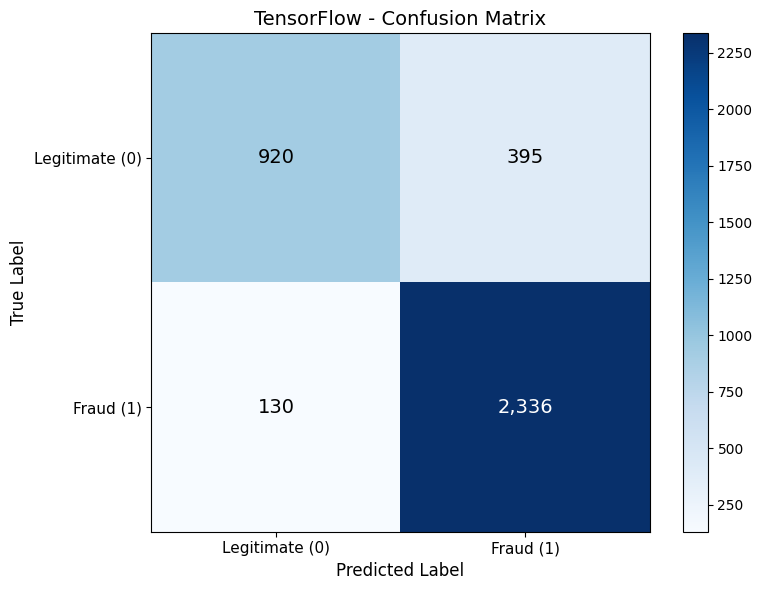

[2/4] ROC curve...


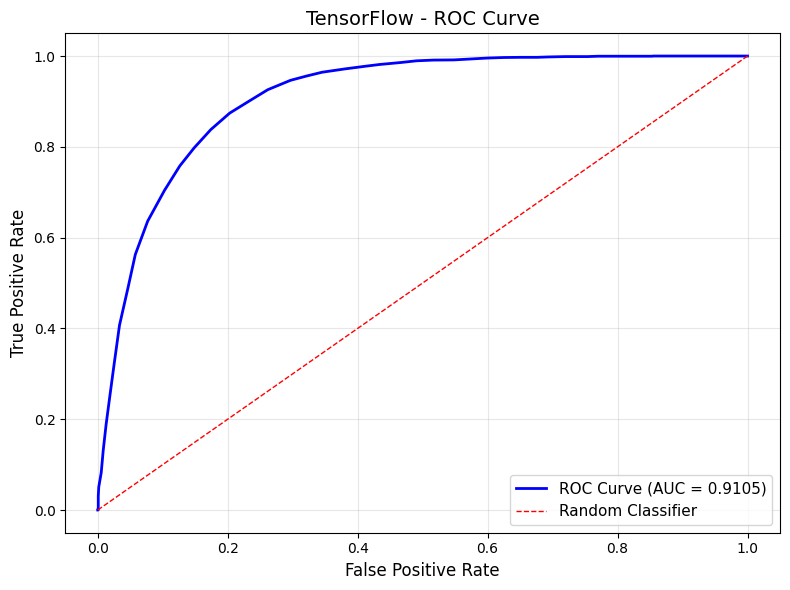

[3/4] Calibration curve...


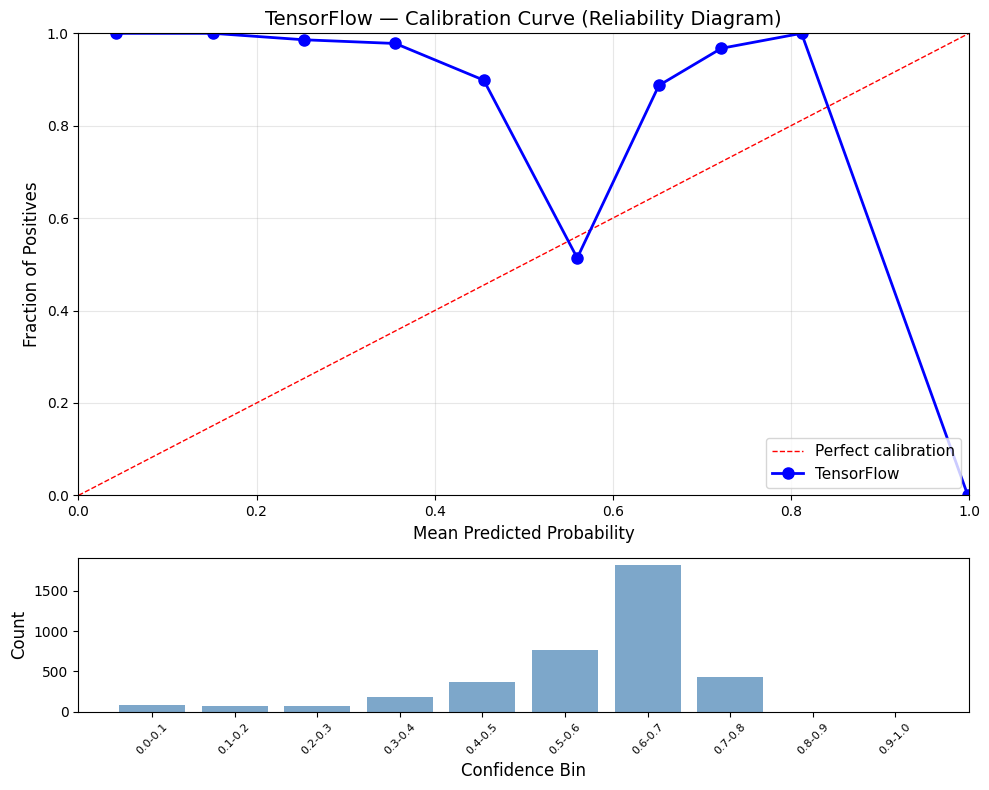

[4/4] Convergence plot...


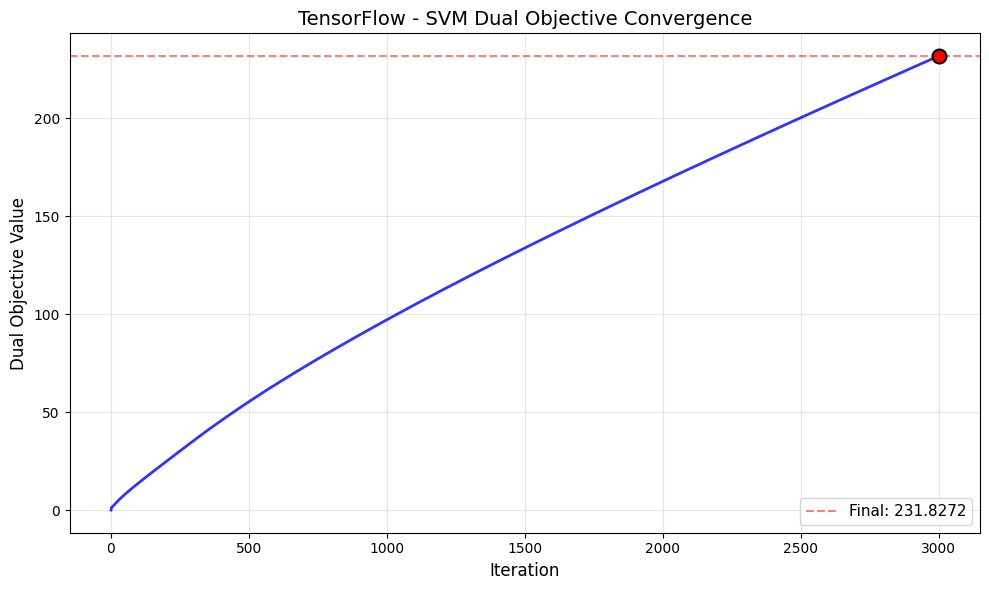


All visualizations saved to results/


In [6]:
# Step 5: Visualizations
print("=" * 60)
print("STEP 5: VISUALIZATIONS")
print("=" * 60)

# All inputs already numpy from Cell 5 (preds_std, probas, obj_history)

# 1. Confusion Matrix
print("\n[1/4] Confusion matrix...")
plot_confusion_matrix(y_test, preds_std, FRAMEWORK,
                      save_path=f"{RESULTS_DIR}/confusion_matrix.png")

# 2. ROC Curve
print("[2/4] ROC curve...")
plot_roc_curve(y_test, probas, FRAMEWORK,
               save_path=f"{RESULTS_DIR}/roc_curve.png")

# 3. Calibration Curve
print("[3/4] Calibration curve...")
plot_calibration_curve(y_test, probas, FRAMEWORK,
                       save_path=f"{RESULTS_DIR}/calibration_curve.png")

# 4. Convergence Plot (obj_history is already list of Python floats)
print("[4/4] Convergence plot...")
plot_svm_convergence(obj_history, FRAMEWORK,
                     save_path=f"{RESULTS_DIR}/svm_convergence.png")

print("\nAll visualizations saved to results/")